# nSpikeTrainExamples

The nspikeTrain class.

Python port of the MATLAB `nSpikeTrainExamples` helpfile (`helpfiles/nSpikeTrainExamples.m`).

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import SignalObj, Covariate, CovColl, Events, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="nSpikeTrainExamples", output_root=OUTPUT_ROOT, expected_count=6)

def capture(label, fn):
    """Save any prior figure, then run ``fn`` on a clean canvas and register
    the result with the tracker. Bypasses the placeholder so axis ticks,
    labels, spines, and titles are preserved (no set_axis_off() leakage,
    no overlapping annotation text)."""
    __tracker._save_active()
    __tracker.count += 1
    plt.close("all")
    fig = plt.figure(figsize=(8.0, 4.5))
    fig.add_subplot(1, 1, 1)
    fn()
    __tracker._active_fig = plt.gcf()
    __tracker._active_ax = plt.gca()


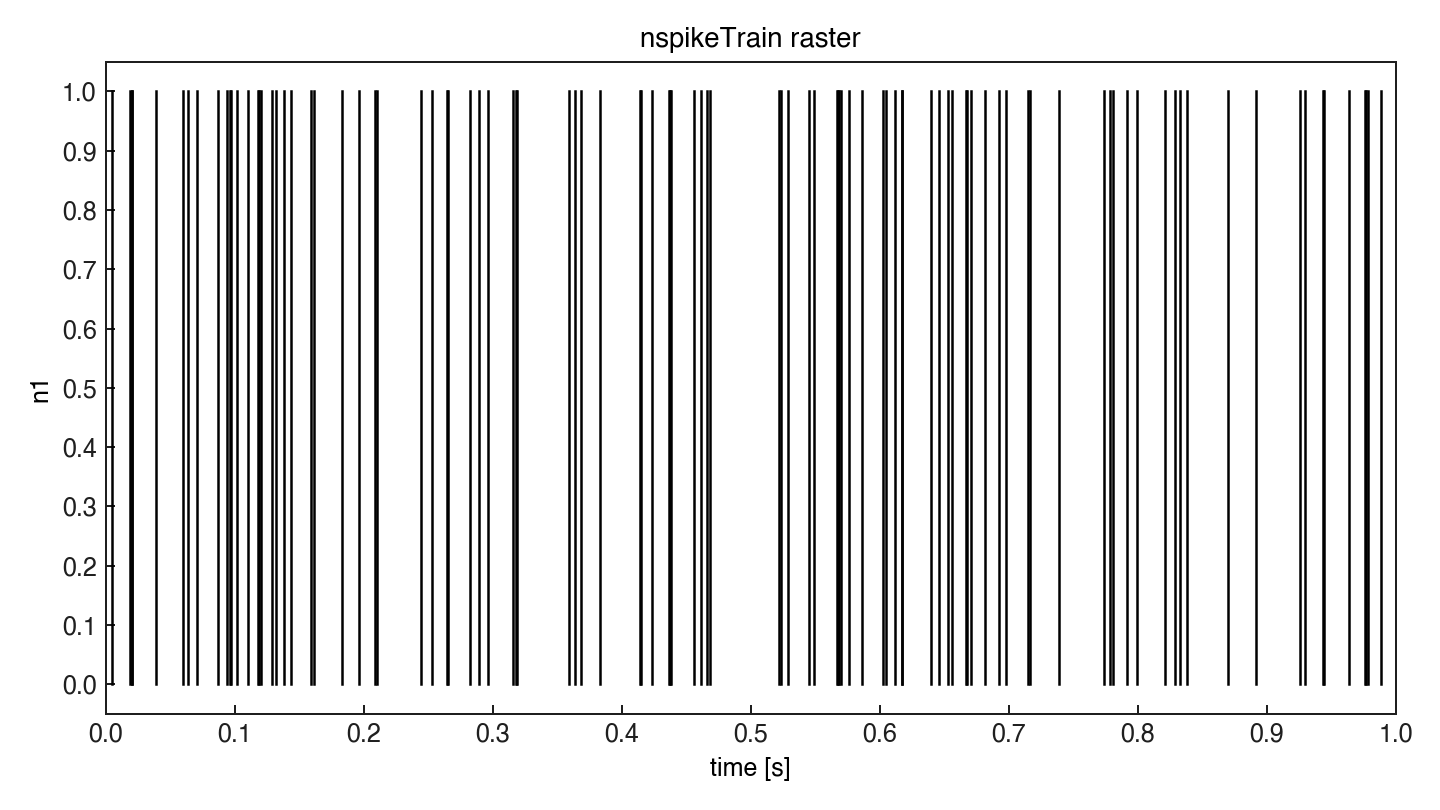

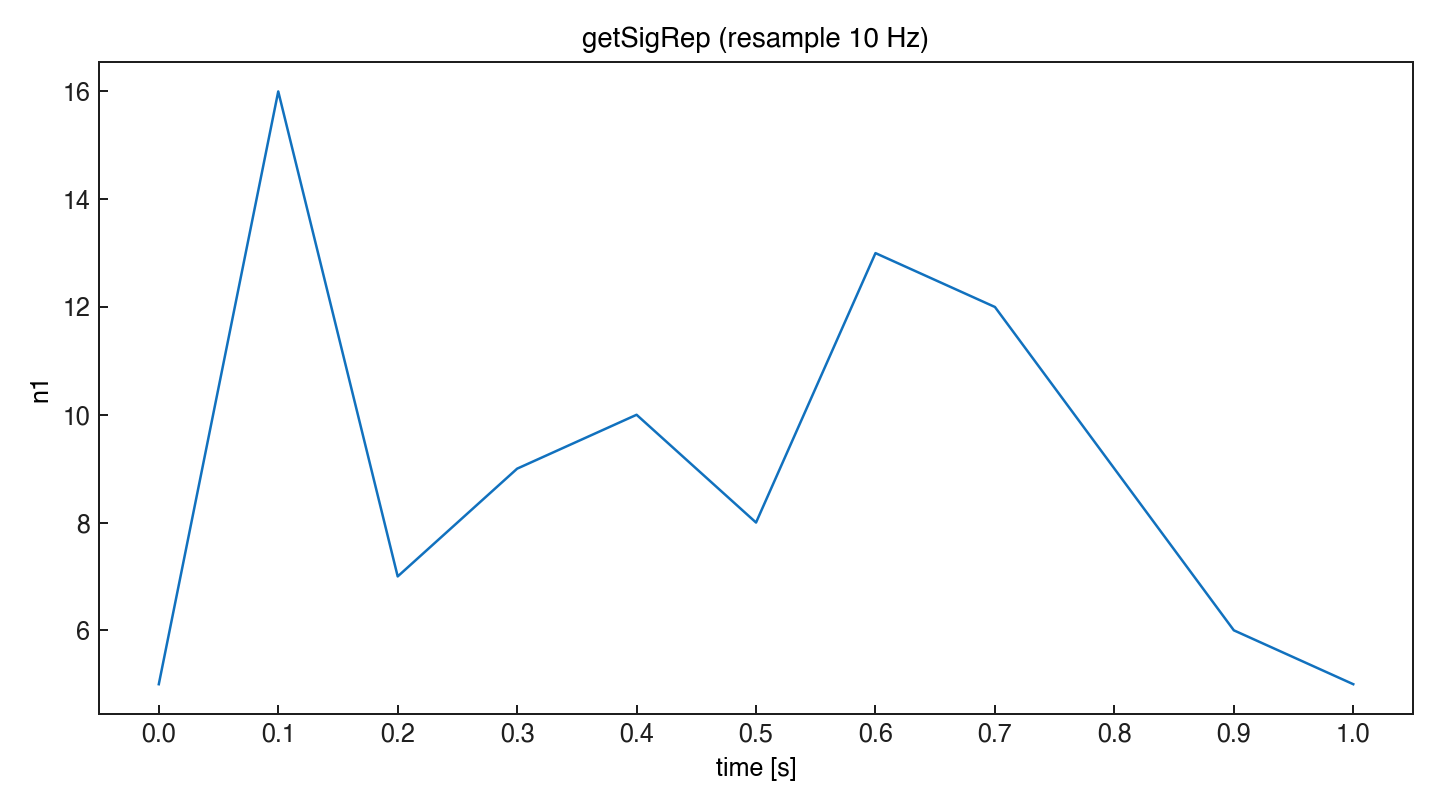

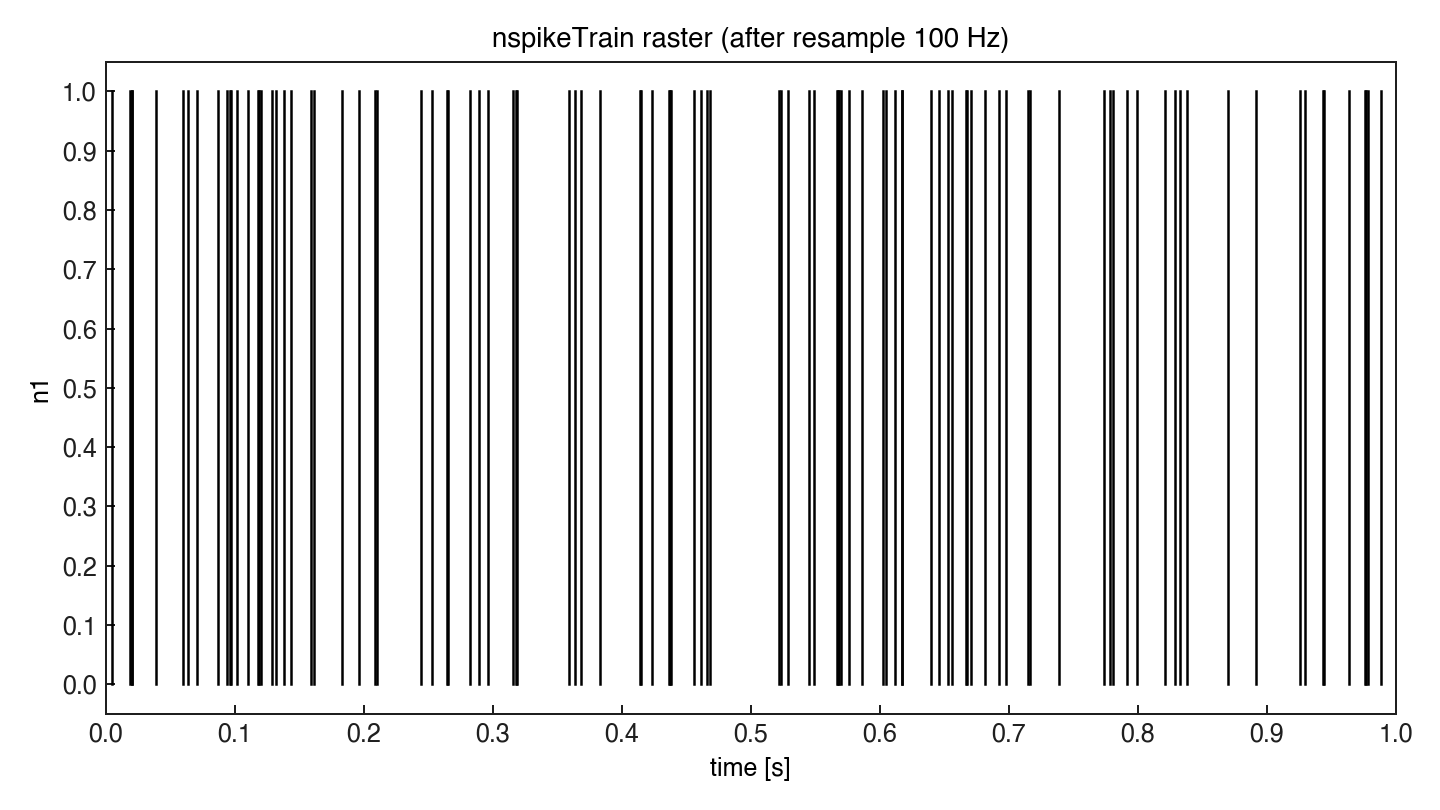

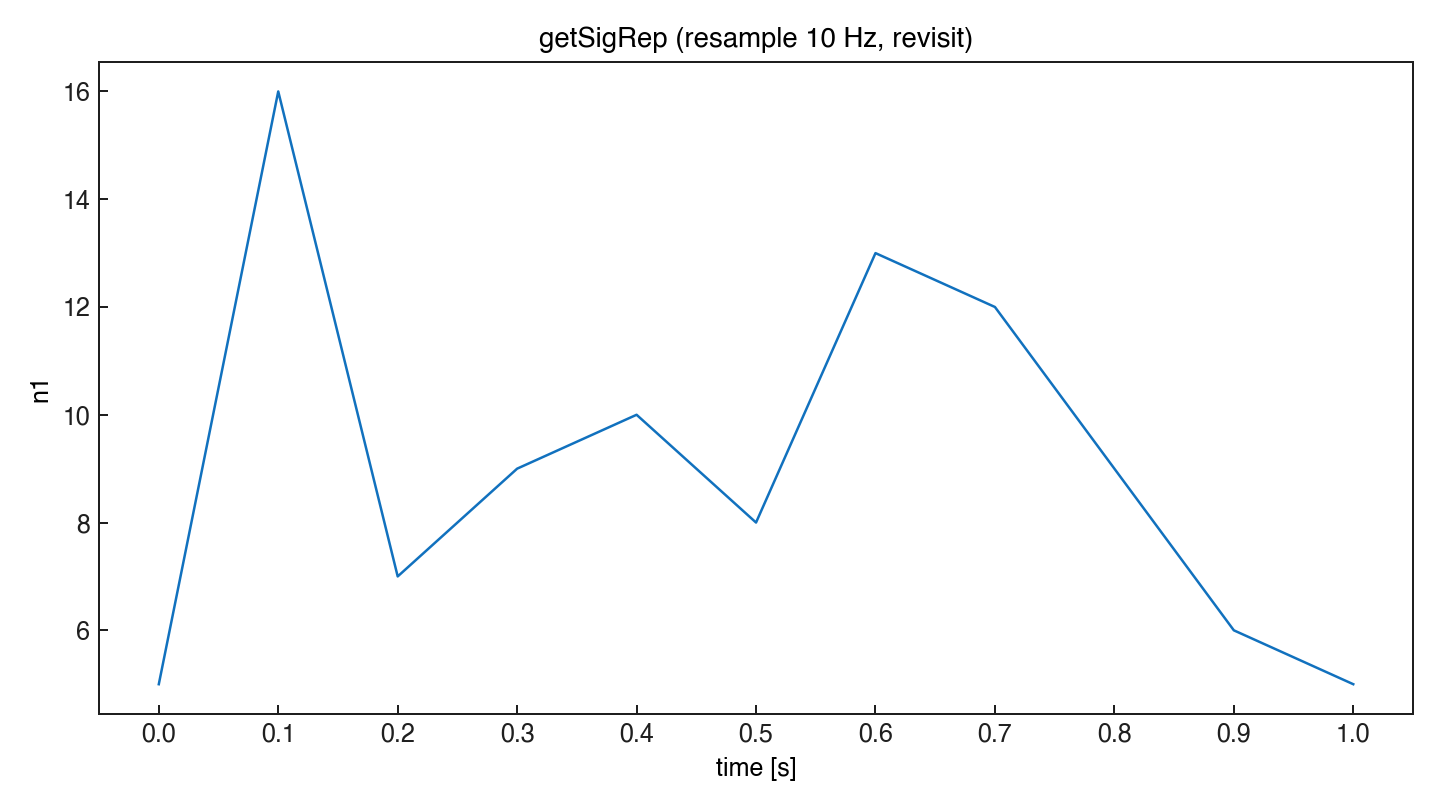

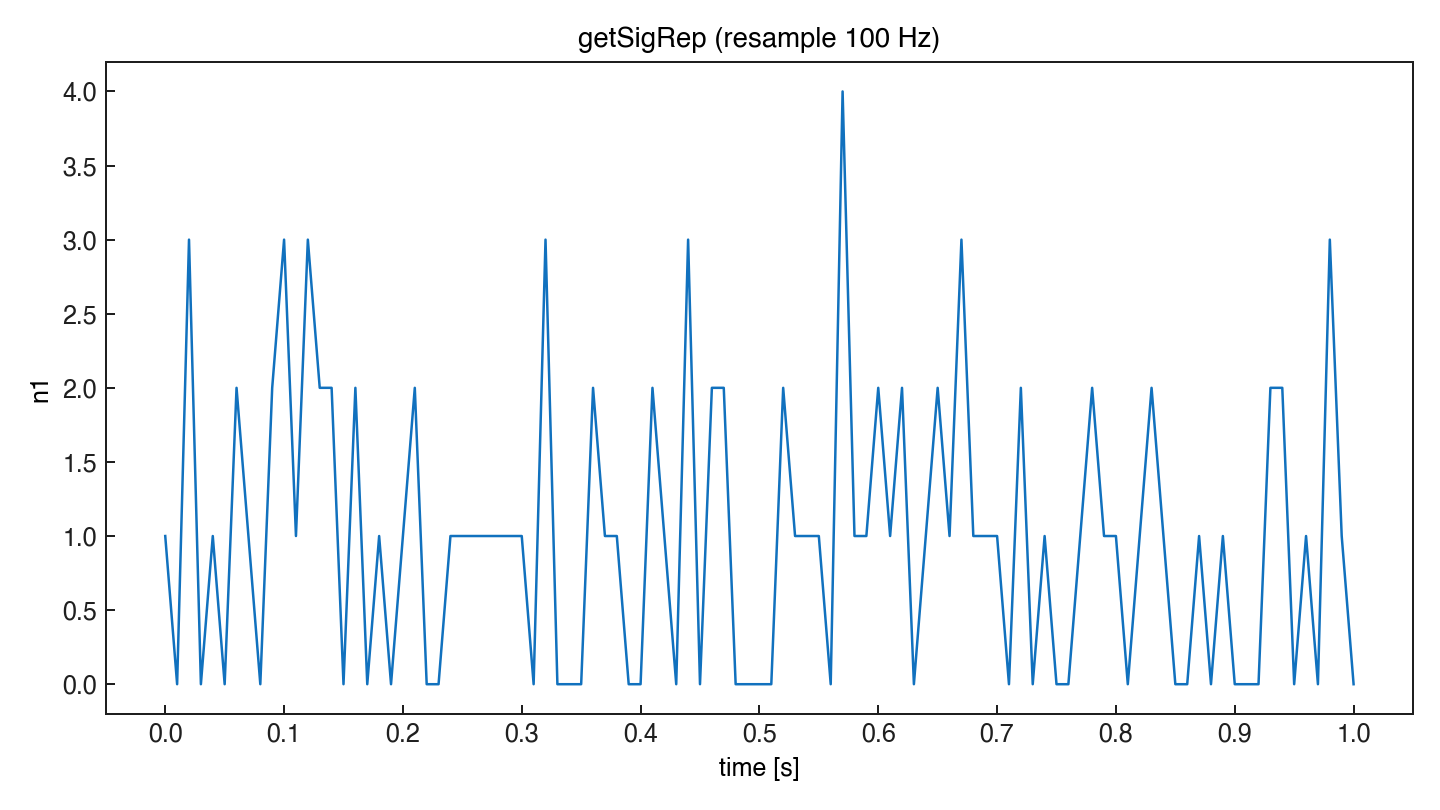

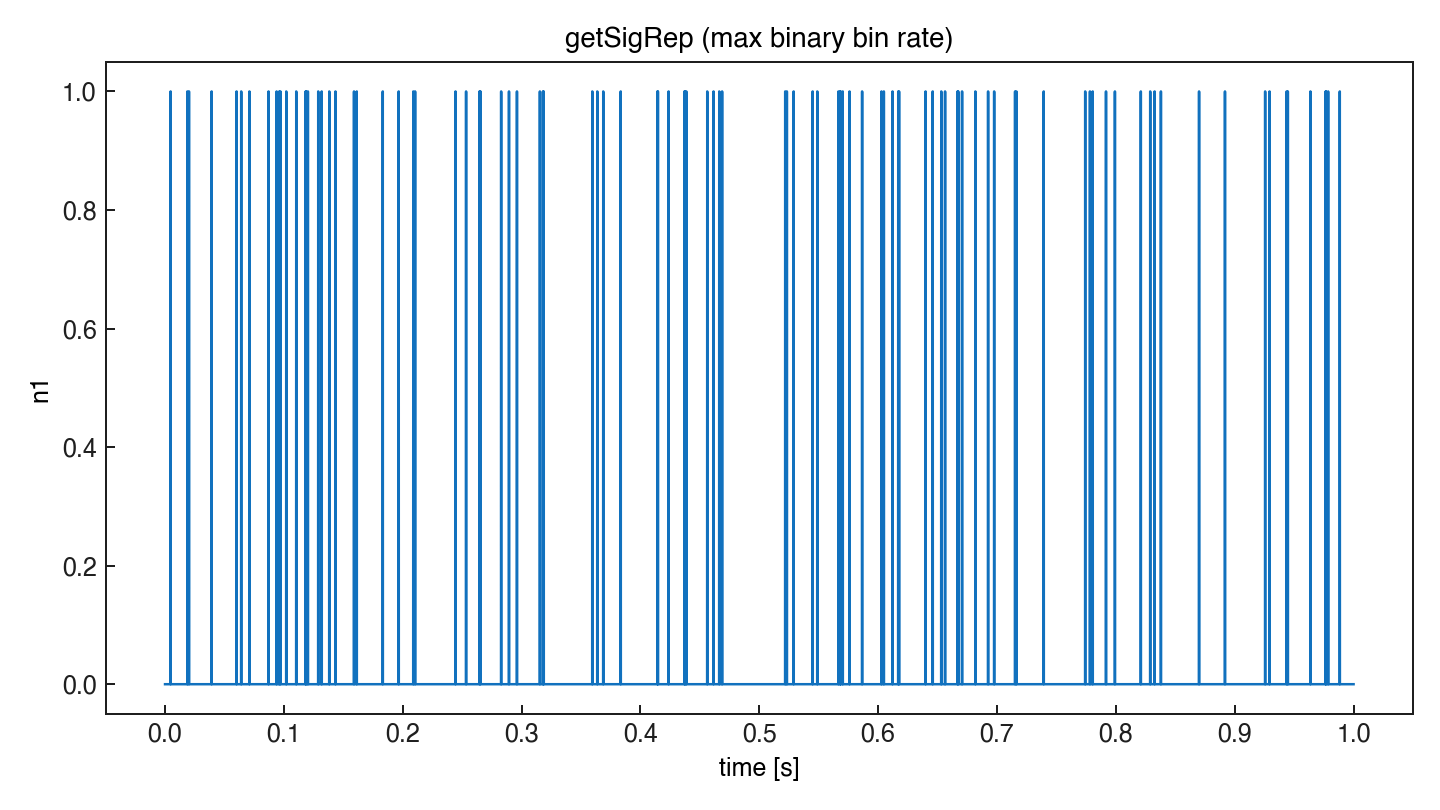

In [ ]:
spikeTimes = np.sort(np.random.rand(100))
spikeTimes = np.unique(np.round(spikeTimes*10000)/10000)
nst = nspikeTrain(spikeTimes, "n1", 1000, 0, 1)  # MATLAB binwidth .001 -> sampleRate 1000

def _raster():
    nst.plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_title("nspikeTrain raster")
    plt.tight_layout()

capture("nst.plot() — raster", _raster)

def _sig10():
    nst.resample(10); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (resample 10 Hz)")
    plt.tight_layout()

capture("signal rep @ 10 Hz", _sig10)

def _raster_resampled():
    # MATLAB live-editor auto-rendered the nspikeTrain object after the
    # 100 Hz resample as a raster before the getSigRep plot
    # (helpfiles/nSpikeTrainExamples_03.png). Mirror that here.
    nst.resample(100); nst.plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_title("nspikeTrain raster (after resample 100 Hz)")
    plt.tight_layout()

capture("nst.plot() raster after 100 Hz resample", _raster_resampled)

def _sig10_revisit():
    # MATLAB live-editor also produced a re-render of the 10 Hz signal
    # representation in the 100 Hz section
    # (helpfiles/nSpikeTrainExamples_04.png). Mirror that here.
    nst.resample(10); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (resample 10 Hz, revisit)")
    plt.tight_layout()

capture("signal rep @ 10 Hz (revisit)", _sig10_revisit)

def _sig100():
    nst.resample(100); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (resample 100 Hz)")
    plt.tight_layout()

capture("signal rep @ 100 Hz", _sig100)

def _sig_bin():
    nst.resample(1.0 / nst.getMaxBinSizeBinary()); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (max binary bin rate)")
    plt.tight_layout()

capture("signal rep @ max binary bin rate", _sig_bin)
__tracker.finalize()
